In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

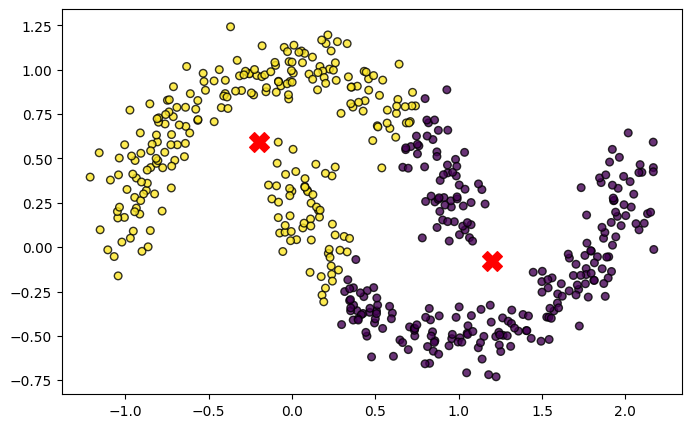

In [68]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_kmeans,
    cmap="viridis",
    s=30,
    edgecolor="k",
    alpha=0.8,
)

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=200,
    marker="X",
)

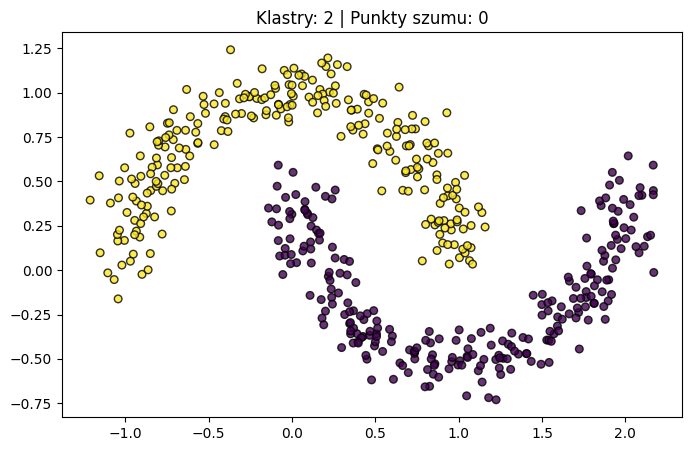

In [70]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

# 2. Wykres
plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_dbscan,
    cmap="viridis",
    s=30,
    edgecolor="k",
    alpha=0.8,
)

plt.title(f"Klastry: {n_clusters} | Punkty szumu: {n_noise}")
plt.show()

# exer 2

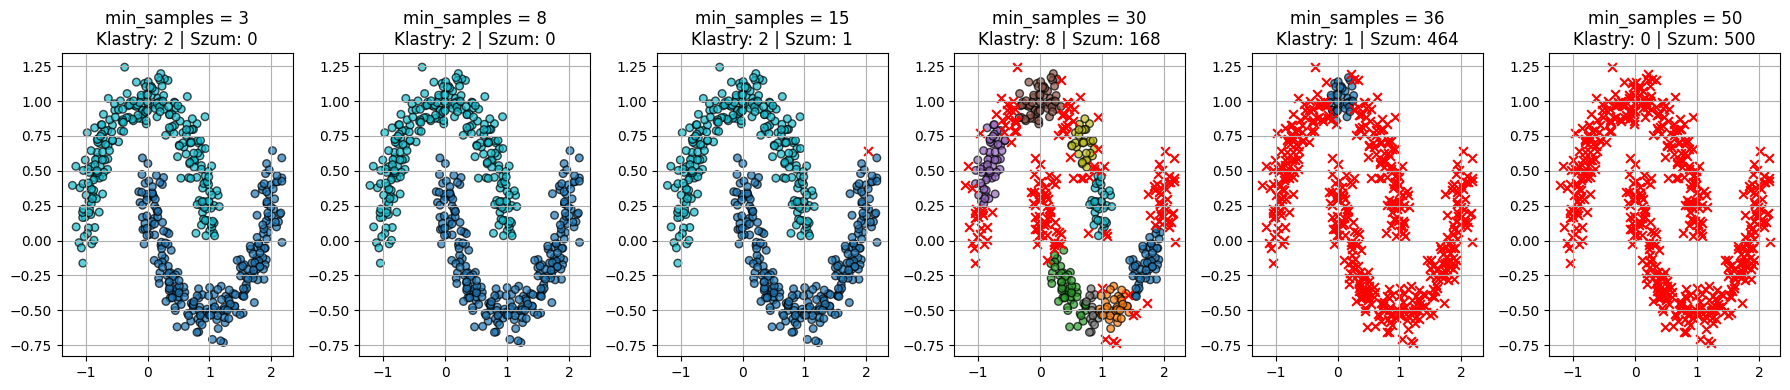

In [17]:
list_min_samples = [3, 8, 15, 30,36, 50]
fig, axes = plt.subplots(1, len(list_min_samples), figsize=(18, 4))

for ax, n_samples in zip(axes, list_min_samples):
    dbscan = DBSCAN(eps=0.2, min_samples=n_samples)
    labels = dbscan.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    cluster_mask = labels != -1
    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        c=labels[cluster_mask],
        cmap="tab10",
        s=30,
        edgecolor="k",
        alpha=0.7,
    )

    noise_mask = labels == -1
    ax.scatter(
        X[noise_mask, 0],
        X[noise_mask, 1],
        c="red",
        marker="x",
        s=40,
        label="Szum (-1)",
    )

    ax.set_title(
        f"min_samples = {n_samples}\nKlastry: {n_clusters} | Szum: {n_noise}"
    )
    ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# min samples = 3 czyli lacza sie najblizsze 3 punkty - minimalna liczba punktow
# w promieniu epsilon
# min samples = 50 laczy sie 50 najblizszych punktow wiec mamy 0 klastrow

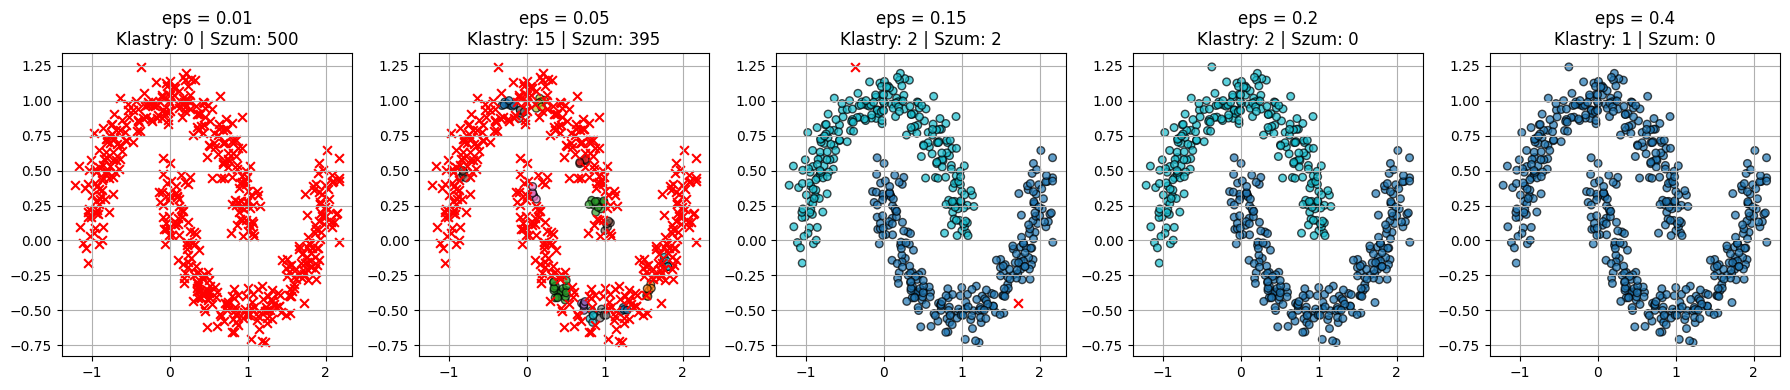

In [19]:
eps_list = [0.01, 0.05, 0.15, 0.2, 0.4]
fig, axes = plt.subplots(1, len(eps_list), figsize=(18, 4))

for ax, eps_val in zip(axes, eps_list):
    dbscan = DBSCAN(eps=eps_val, min_samples=5)
    labels = dbscan.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    cluster_mask = labels != -1
    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        c=labels[cluster_mask],
        cmap="tab10",
        s=30,
        edgecolor="k",
        alpha=0.7,
    )

    noise_mask = labels == -1
    ax.scatter(
        X[noise_mask, 0],
        X[noise_mask, 1],
        c="red",
        marker="x",
        s=40,
        label="Szum (-1)",
    )

    ax.set_title(
        f"eps = {eps_val}\nKlastry: {n_clusters} | Szum: {n_noise}"
    )
    ax.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# eps 0.01 - zaden punkt nie ma liczby sasiadow w takim promieniu wiec klastrow mamy 0 
# eps 0.4 promien jest na tyle duzy ze lacza sie wszystkie punkty 

# exercise 3

In [21]:
from sklearn.datasets import make_blobs


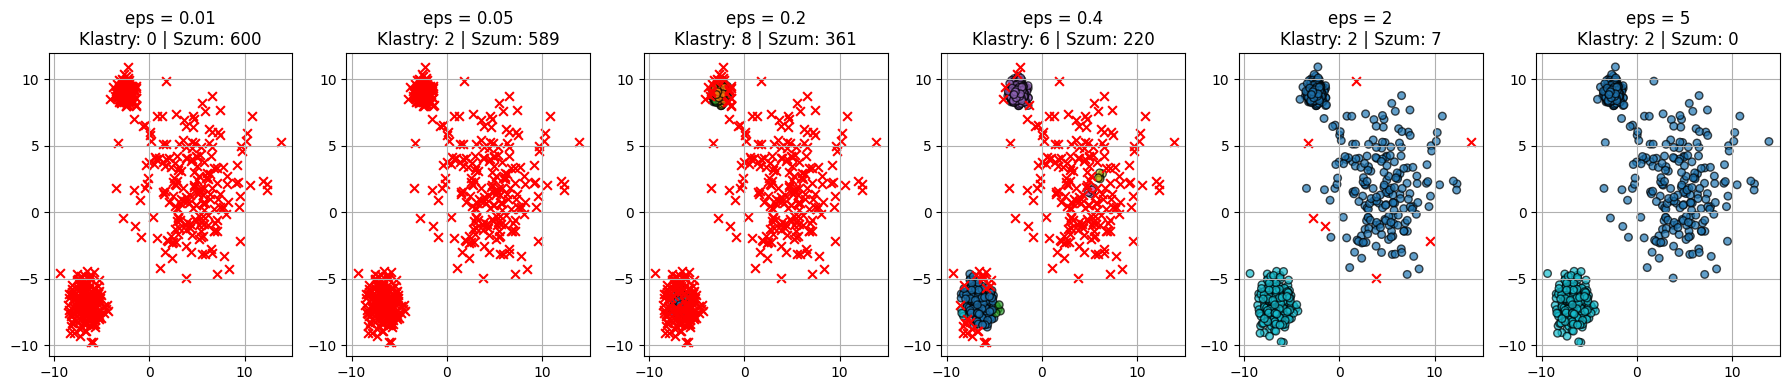

In [22]:
X_2, y_2 = make_blobs(n_samples=600, centers=3, cluster_std=[0.5, 3.0, 1], random_state=42)

eps_list = [0.01, 0.05,0.2, 0.4,2,5]
fig, axes = plt.subplots(1, len(eps_list), figsize=(18, 4))

for ax, eps_val in zip(axes, eps_list):
    dbscan = DBSCAN(eps=eps_val, min_samples=5)
    labels = dbscan.fit_predict(X_2)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    cluster_mask = labels != -1
    ax.scatter(
        X_2[cluster_mask, 0],
        X_2[cluster_mask, 1],
        c=labels[cluster_mask],
        cmap="tab10",
        s=30,
        edgecolor="k",
        alpha=0.7,
    )

    noise_mask = labels == -1
    ax.scatter(
        X_2[noise_mask, 0],
        X_2[noise_mask, 1],
        c="red",
        marker="x",
        s=40,
        label="Szum (-1)",
    )

    ax.set_title(
        f"eps = {eps_val}\nKlastry: {n_clusters} | Szum: {n_noise}"
    )
    ax.grid(True)

plt.tight_layout()
plt.show()

In [23]:
#dbscann uzywa jednego eps dla calego zbioru danych wiec jnie potrafi identyfikowac klastrow o roznej gestosci.
#jak mamy eps 5 to mamy tylko dwa klastry a jak mamy eps 0,2 to mamy 8 klastrow 

# 2 czesc

In [37]:
from sklearn.neighbors import NearestNeighbors

In [38]:
df = pd.read_csv('Mall_Customers.csv')
df.head(2)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [40]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [87]:
X_3 = df.drop(['CustomerID', 'Genre','Age'], axis=1)

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_3)

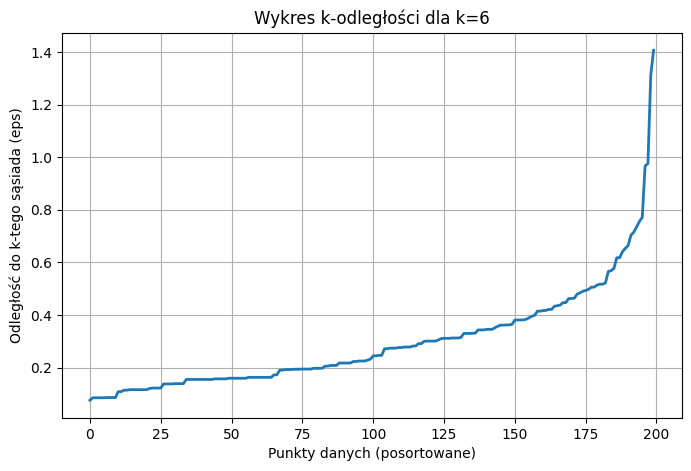

In [89]:
k=6
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2)
plt.title(f'Wykres k-odległości dla k={k}')
plt.xlabel('Punkty danych (posortowane)')
plt.ylabel('Odległość do k-tego sąsiada (eps)')
plt.grid(True)

In [117]:
optymalne_eps = 0.45

dbscan = DBSCAN(eps=optymalne_eps, min_samples=k)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Wybrane eps: {optymalne_eps}")
print(f"Liczba wykrytych klastrów: {n_clusters}")
print(f"Liczba punktów szumu: {n_noise}")

Wybrane eps: 0.45
Liczba wykrytych klastrów: 5
Liczba punktów szumu: 29


Text(0.5, 1.0, 'Klastry: 5 | Punkty szumu: 29')

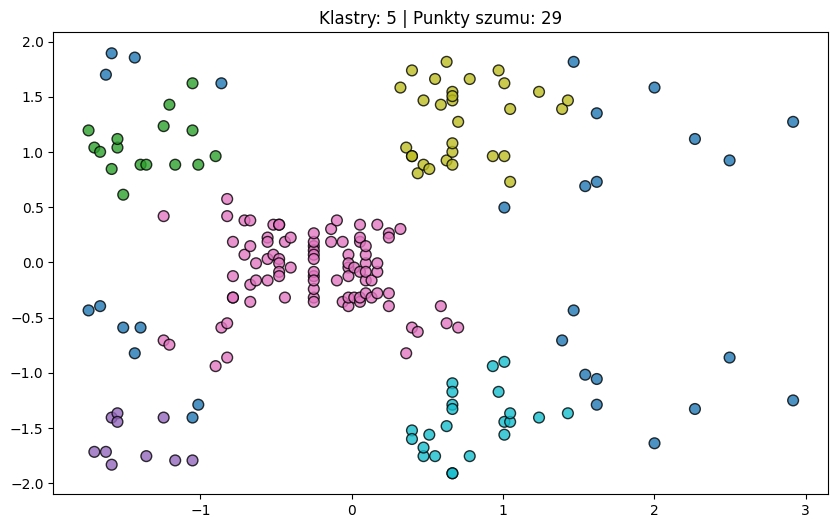

In [118]:
plt.figure(figsize=(10, 6))

# Wykres 2D
plt.scatter(
    X_scaled[:, 0], # Oś X: Dochód
    X_scaled[:, 1], # Oś Y: Wydatki
    c=labels, 
    cmap='tab10', 
    s=60, 
    edgecolor='k',
    alpha=0.8
)
plt.title(f"Klastry: {n_clusters} | Punkty szumu: {n_noise}")


In [102]:
#kmeans

In [103]:
wcss = []

# checking number of clasters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled) 
    wcss.append(kmeans.inertia_)
    
for k, wcss_val in zip(range(1, 11), wcss):
    print(f"number (k): {k} : {wcss_val}")

number (k): 1 : 400.0
number (k): 2 : 273.6688866264201
number (k): 3 : 157.70400815035947
number (k): 4 : 109.22822707921345
number (k): 5 : 65.56840815571681
number (k): 6 : 60.13287487193422
number (k): 7 : 49.668244837367986
number (k): 8 : 37.31912287833883
number (k): 9 : 32.49508119910091
number (k): 10 : 30.05932269404221


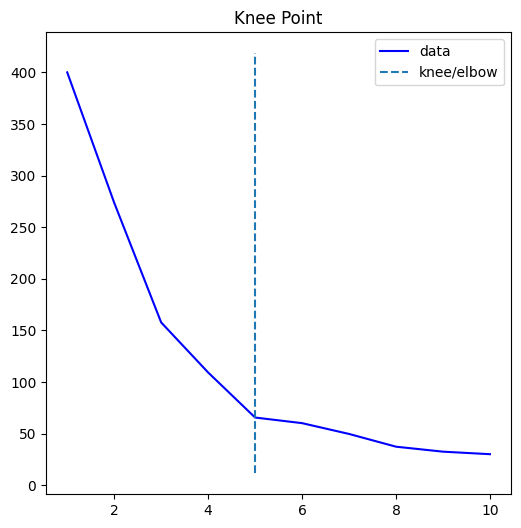

In [106]:
from kneed import KneeLocator
KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing").plot_knee()

In [107]:
kmeans = KMeans(n_clusters=5, random_state=42)

In [108]:
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [120]:
df_copy_kmeans = df.copy()
df_copy_kmeans ['Cluster'] = kmeans.labels_

In [121]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

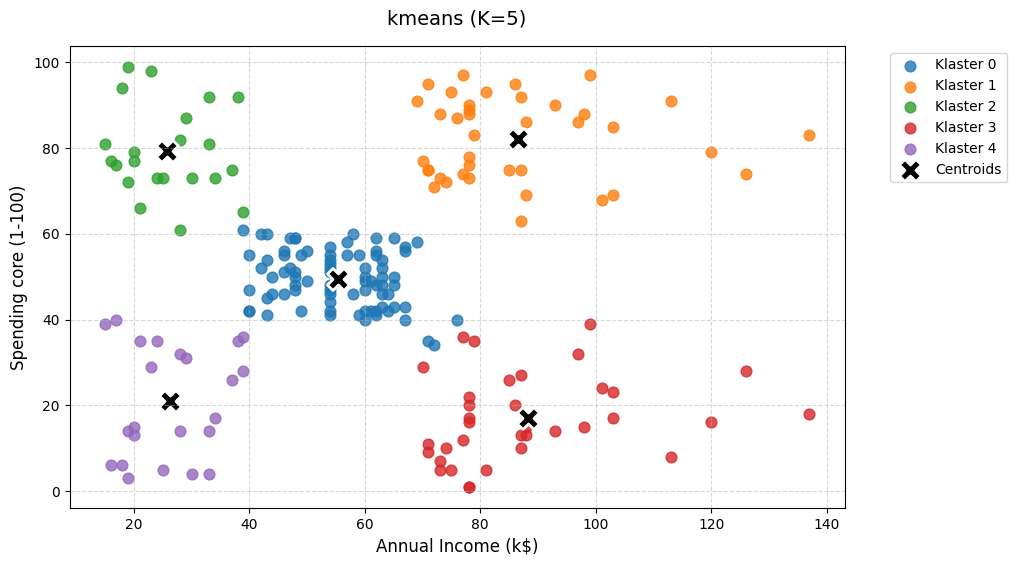

In [122]:
plt.figure(figsize=(10, 6))
for i in range(5):
    klaster_dane = df[df['Cluster'] == i]
    
    plt.scatter(klaster_dane['Annual Income (k$)'], 
                klaster_dane['Spending Score (1-100)'], 
                s=60, label=f'Klaster {i}', alpha=0.8)

plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c='black', marker='X', 
            edgecolors='white', linewidths=2, label='Centroids')
plt.title('kmeans (K=5)', fontsize=14, pad=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending core (1-100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

In [119]:
#kmeans jest lepsze

# exer 5

In [130]:
df_copy_dbscan = df.copy()
df_copy_dbscan['Cluster'] = dbscan.labels_

In [131]:
df_copy_dbscan.head(2)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,0


In [133]:
noise = df_copy_dbscan[df_copy_dbscan['Cluster'] == -1]

In [136]:
noise

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,-1
4,5,Female,31,17,40,-1
7,8,Female,23,18,94,-1
11,12,Female,35,19,99,-1
16,17,Female,35,21,35,-1
18,19,Male,52,23,29,-1
19,20,Female,35,23,98,-1
20,21,Male,35,24,35,-1
34,35,Female,49,33,14,-1
36,37,Female,42,34,17,-1


In [137]:
#widac ze sa to nietypowi klienci - ktos zarabia 113 k a wydaje 8 

In [138]:
from sklearn.ensemble import IsolationForest

In [146]:
n_noise = len(noise)

In [152]:
percent_of_noise = n_noise/len(df_copy_dbscan)
iso = IsolationForest(contamination=percent_of_noise, random_state=42)
iso_labels = iso.fit_predict(X_scaled)

dbscan_anomalies = set(noise.index)
iso_anomalies = set(df[iso_labels == -1].index)

wspolne_anomalie = dbscan_anomalies.intersection(iso_anomalies)

print(f"Anomalie wg DBSCAN: {len(dbscan_anomalies)}")
print(f"Anomalie wg Isolation Forest: {len(iso_anomalies)}")
print(f"Wspólne dla obu modeli: {len(wspolne_anomalie)}")

Anomalie wg DBSCAN: 29
Anomalie wg Isolation Forest: 29
Wspólne dla obu modeli: 17


In [159]:
df_copy_dbscan['Iso_Cluster'] = iso_labels
noise_both = df_copy_dbscan[(df_copy_dbscan['Cluster'] == -1) & (df_copy_dbscan['Iso_Cluster'] == -1)]
noise_both

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Iso_Cluster
0,1,Male,19,15,39,-1,-1
4,5,Female,31,17,40,-1,-1
7,8,Female,23,18,94,-1,-1
11,12,Female,35,19,99,-1,-1
19,20,Female,35,23,98,-1,-1
41,42,Male,24,38,92,-1,-1
184,185,Female,41,99,39,-1,-1
185,186,Male,30,99,97,-1,-1
187,188,Male,28,101,68,-1,-1
192,193,Male,33,113,8,-1,-1


In [166]:
szum_w_dowolnym = df_copy_dbscan[(df_copy_dbscan['Cluster'] == -1) | (df_copy_dbscan['Iso_Cluster'] == -1)]
len(szum_w_dowolnym)

41